In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [22]:
import os
import pickle
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
from pymoo.indicators.hv import Hypervolume

from util import natural_key, load_yaml

In [3]:
def compute_hypervolume_mixed(front_raw: np.ndarray, ε: float = 1e-6) -> float:
    """
    Compute hypervolume for a 3-objective Pareto front where:
        - front_raw[:, 0] = accuracy (to be maximized)
        - front_raw[:, 1] = num_parameters (to be minimized)
        - front_raw[:, 2] = inference_time (to be minimized)

    We first convert everything into minimization form by flipping accuracy → -accuracy,
    then build a reference point slightly above the “worst” in each dimension,
    and finally call pymoo’s Hypervolume on that minimization front.
    Args:
        front_raw (np.ndarray): shape=(N, 3) with columns [acc, params, time].
        ε (float): tiny margin to add to the reference point.
    Returns:
        float: the hypervolume (in the original mixed‐obj space).
    """
    if front_raw.size == 0:
        return 0.0
    # 1) Build minimization front: acc → -acc, params & time unchanged
    front_min = front_raw.copy()
    front_min[:, 0] *= -1.0   # flip accuracy
    # 2) Construct the reference point (for each column, take max(front_min[:,j]) + ε)
    ref = np.max(front_min, axis=0) + ε
    # 3) Call pymoo’s Hypervolume (which expects a minimization front and ref_point)
    hv_indicator = Hypervolume(ref_point=ref)
    hv_value     = hv_indicator(front_min)
    return float(hv_value)

In [4]:
def load_pareto_history(filepath="pareto_history.pkl"):
    """
    Carga el archivo pickle que contiene fronts_history.
    Devuelve un dict: {generacion: {nivel_frente: [registros...]}}
    """
    with open(filepath, "rb") as f:
        history = pickle.load(f)
    return history

In [5]:
def plot_hypervolume_over_epochs(main_path, experiment_pattern="exp1_repeat"):

    folder_list = [f for f in os.listdir(main_path) if experiment_pattern in f]
    print(f"Found {len(folder_list)} folders matching the pattern '{experiment_pattern}'.")
    plt.figure(figsize=(10, 6))
    num_plots = 0

    for folder in folder_list:
        history_path = os.path.join(main_path, folder, "pareto_history.pkl")
        if not os.path.exists(history_path):
            continue

        with open(history_path, "rb") as pf:
            history = pickle.load(pf)

        generations = sorted(history.keys())
        hypervolumes = [history[gen].get("hypervolume", 0.0) for gen in generations]

        if generations and any(hypervolumes):
            plt.plot(generations, hypervolumes, marker='o', label=folder)
            num_plots += 1

    plt.title("Hypervolume over Generations for Each Experiment")
    plt.xlabel("Generation")
    plt.ylabel("Hypervolume")
    if num_plots > 0:
        plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [62]:
def pareto_history_to_df(filepath="pareto_history.pkl", generation=1):
    """
    Convierte la historia de Pareto guardada en filepath en un DataFrame
    para la generación 'generation', con columnas:
        generation, front_level, accuracy, params, inference_time
    """
    history = load_pareto_history(filepath)
    if generation not in history:
        raise ValueError(f"Generation {generation} not found in history.")
    
    gen_dict = history[generation]
    records = []
    for level, recs in gen_dict.items():
        # saltamos la métrica hypervolume
        if level == "hypervolume":
            continue
        for rec in recs:
            records.append({
                "id":             rec["id"],
                "generation":      generation,
                "front_level":     level,
                "accuracy":        rec["accuracy"],
                "params":          rec["params"],
                "inference_time":  rec["inference_time"]
            })
    return pd.DataFrame(records)

In [7]:
def plot_pareto_evolution(history, dims="3d",
                            x="params", y="inference_time", z="accuracy",
                            width=1200, height=800, y_range=None):
    """
    Plot the evolution of Pareto fronts over generations en 2D o 3D con tooltips
    formateados a 2 decimales y unidad.
    """
    # 1) Flatten the history into a DataFrame, skipping the "hypervolume" key
    rows = []
    for gen, fronts in history.items():
        for level, recs in fronts.items():
            # Skip any non-integer key (e.g. "hypervolume")
            if not isinstance(level, int):
                continue

            for rec in recs:
                rows.append({
                    "generation": gen,
                    "front_level": level,
                    "accuracy": rec["accuracy"],
                    "params": rec["params"],
                    "inference_time": rec["inference_time"]
                })

    df = pd.DataFrame(rows)

    # 2) Build the plot in 3D or 2D
    if dims == "3d":
        fig = px.scatter_3d(
            df,
            x=x, y=y, z=z,
            color="front_level",
            animation_frame="generation",
            width=width, height=height,
            title="Pareto Front Evolution (3D)",
            labels={
                x: "Params (M)",
                y: "Inference Time (µs)",
                z: "Accuracy (%)",
                "front_level": "Front Level",
                "generation": "Generation"
            },
            custom_data=["front_level", "generation"]
        )
        fig.update_traces(
            marker=dict(size=4),
            hovertemplate=(
                "Params: %{x:.2f} M<br>"
                "Inference Time: %{y:.2f} µs<br>"
                "Accuracy: %{z:.2f}%<br>"
                "Front Level: %{customdata[0]}<br>"
                "Generation: %{customdata[1]}<extra></extra>"
            )
        )
        fig.update_layout(
            scene=dict(
                yaxis=dict(range=[df[y].min() * 0.9, df[y].max() * 1.5],),
            ),
            margin=dict(l=20, r=20, t=50, b=20)
        )

    else:
        # 2D scatter
        fig = px.scatter(
            df,
            x=x, y=y,
            color="front_level",
            animation_frame="generation",
            width=width, height=height,
            title="Pareto Front Evolution (2D)",
            labels={
                x: "Params (M)",
                y: "Inference Time (µs)",
                "front_level": "Front Level",
                "generation": "Generation"
            },
            custom_data=["front_level", "generation"]
        )
        fig.update_traces(
            marker=dict(size=6),
            hovertemplate=(
                "Params: %{x:.2f} M<br>"
                "Inference Time: %{y:.2f} µs<br>"
                "Front Level: %{customdata[0]}<br>"
                "Generation: %{customdata[1]}<extra></extra>"
            )
        )
        if y_range is not None:
            fig.update_layout(yaxis=dict(range=y_range))
        fig.update_layout(margin=dict(l=20, r=20, t=50, b=20))

    fig.show()

In [8]:
history = load_pareto_history("experiment_cifar10_moqnas/exp3_repeat_1/pareto_history.pkl")

In [9]:
# To show 3D animation:
plot_pareto_evolution(history, dims="3d",
                    x="params", y="inference_time", z="accuracy")

# Hypervolume

In [16]:
import os

Found 2 folders matching the pattern 'exp3_repeat'.


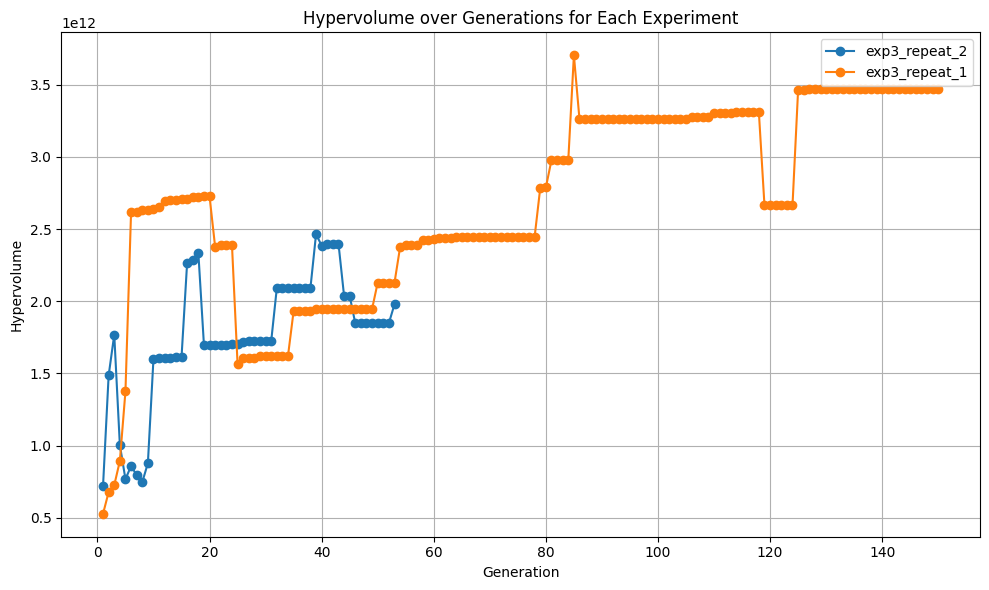

In [17]:
# Example usage:
main_path = "experiment_cifar10_moqnas"
plot_hypervolume_over_epochs(main_path, experiment_pattern="exp3_repeat")


Found 3 folders matching the pattern 'exp2_repeat'.


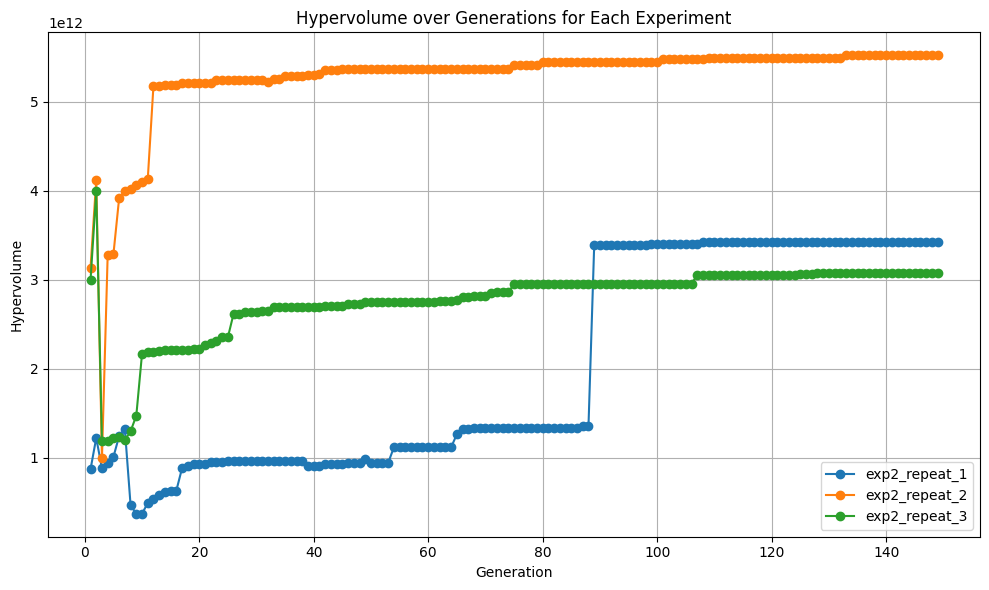

In [18]:
# Example usage:
main_path = "experiment_cifar10_nsga"
plot_hypervolume_over_epochs(main_path, experiment_pattern="exp2_repeat")